In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
wine_data = load_wine()

df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
df["actual_class"] = wine_data.target
print(df.head())

   alcohol  malic_acid  ...  proline  actual_class
0    14.23        1.71  ...   1065.0             0
1    13.20        1.78  ...   1050.0             0
2    13.16        2.36  ...   1185.0             0
3    14.37        1.95  ...   1480.0             0
4    13.24        2.59  ...    735.0             0

[5 rows x 14 columns]


In [3]:
print(df.shape)
print(df.columns)
print(df.describe())
print(df.isnull().sum())
print(df.info())

(178, 14)
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'actual_class'],
      dtype='str')
          alcohol  malic_acid  ...      proline  actual_class
count  178.000000  178.000000  ...   178.000000    178.000000
mean    13.000618    2.336348  ...   746.893258      0.938202
std      0.811827    1.117146  ...   314.907474      0.775035
min     11.030000    0.740000  ...   278.000000      0.000000
25%     12.362500    1.602500  ...   500.500000      0.000000
50%     13.050000    1.865000  ...   673.500000      1.000000
75%     13.677500    3.082500  ...   985.000000      2.000000
max     14.830000    5.800000  ...  1680.000000      2.000000

[8 rows x 14 columns]
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0


In [4]:
X = df.drop("actual_class", axis=1)
print(X.head())

   alcohol  malic_acid   ash  ...   hue  od280/od315_of_diluted_wines  proline
0    14.23        1.71  2.43  ...  1.04                          3.92   1065.0
1    13.20        1.78  2.14  ...  1.05                          3.40   1050.0
2    13.16        2.36  2.67  ...  1.03                          3.17   1185.0
3    14.37        1.95  2.50  ...  0.86                          3.45   1480.0
4    13.24        2.59  2.87  ...  1.04                          2.93    735.0

[5 rows x 13 columns]


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.head())

    alcohol  malic_acid  ...  od280/od315_of_diluted_wines   proline
0  1.518613   -0.562250  ...                      1.847920  1.013009
1  0.246290   -0.499413  ...                      1.113449  0.965242
2  0.196879    0.021231  ...                      0.788587  1.395148
3  1.691550   -0.346811  ...                      1.184071  2.334574
4  0.295700    0.227694  ...                      0.449601 -0.037874

[5 rows x 13 columns]


c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning:

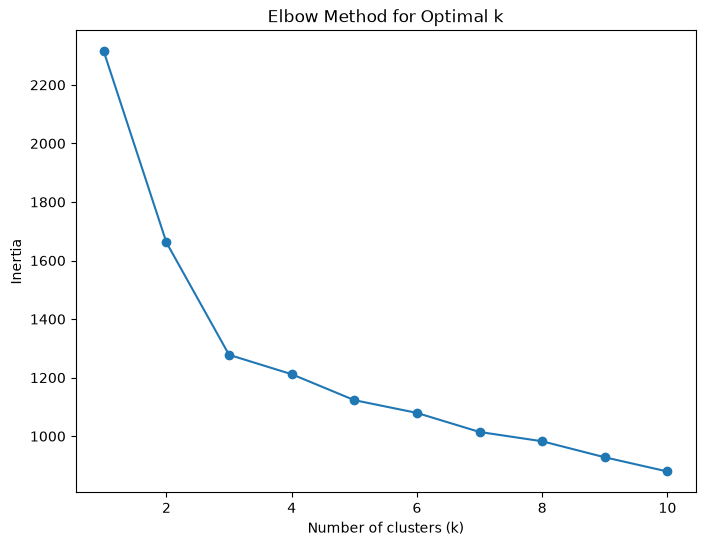

In [7]:
inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_df)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters
df.head()

c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,actual_class,cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,2


In [9]:
df['cluster'].value_counts()

cluster
0    65
2    62
1    51
Name: count, dtype: int64

In [10]:
cluster_summary = df.groupby('cluster').mean()
cluster_summary

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,actual_class
cluster,,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231,1.000000
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824,1.941176
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806,0.048387


In [11]:
simple_cluster_summary = df.groupby('cluster')[
    ["alcohol", "flavanoids", "color_intensity", "proline"]
].mean()

simple_cluster_summary

,alcohol,flavanoids,color_intensity,proline
cluster,,,,
0,12.250923,2.050000,2.973077,510.169231
1,13.134118,0.818824,7.234706,619.058824
2,13.676774,3.003226,5.453548,1100.225806


In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_cluster_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_cluster_df['cluster'] = clusters
pca_cluster_df.head()

,PCA1,PCA2,cluster
0,3.316751,1.443463,2
1,2.209465,-0.333393,2
2,2.516740,1.031151,2
3,3.757066,2.756372,2
4,1.008908,0.869831,2
